In [ ]:
from google.colab import drive
drive.mount('/content/drive')
#/content/drive/MyDrive/Thesis/figures/
# /content/drive/MyDrive/Thesis/datasets/
# /content/drive/MyDrive/Thesis/pickles/

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# PyCaret


In [ ]:
pip install pycaret

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 4.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.4/60.4 kB 5.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.0/58.0 kB 6.8 MB/s eta 0:00:00
INFO: pip is looking at multiple versions of category-encoders to determine which version is compatible with other requirements. This could take a while.
INFO: pip is looking at multiple versions of pmdarima to determine which version is compatible with other requirements. This could take a while.
INFO: pip is looking at multiple versions of pyod to determine which version is compatible with other requirements. This could take a while.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.0/58.0 kB 6.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.3/57.3 kB 6.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.3/57.3 kB 6.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 486.1/486.1 kB 21.7 MB/s eta 0:00:00

In [ ]:
import pandas as pd

In [ ]:
pip show pycaret

Name: pycaret
Version: 3.3.2
Summary: PyCaret - An open source, low-code machine learning library in Python.
Home-page: https://github.com/pycaret/pycaret
Author: Moez Ali
Author-email: moez.ali@queensu.ca
License: MIT
Location: /usr/local/lib/python3.11/dist-packages
Requires: category-encoders, cloudpickle, deprecation, imbalanced-learn, importlib-metadata, ipython, ipywidgets, jinja2, joblib, kaleido, lightgbm, markupsafe, matplotlib, nbformat, numba, numpy, pandas, plotly, plotly-resampler, pmdarima, psutil, pyod, requests, schemdraw, scikit-learn, scikit-plot, scipy, sktime, statsmodels, tbats, tqdm, wurlitzer, xxhash, yellowbrick
Required-by: 


In [ ]:
real_train = pd.read_csv('/content/drive/MyDrive/Thesis/datasets/german_credit_train.csv')
real_test = pd.read_csv('/content/drive/MyDrive/Thesis/datasets/german_credit_test.csv')

# TRTR

Determine the baseline using Train on Real and Test on Real

In [ ]:
from pycaret.classification import ClassificationExperiment

exp = ClassificationExperiment()
exp.setup(
    data=real_train,
    test_data=real_test,
    target="target",
    session_id=42,
    index=False
)

,Description,Value
0,Session id,42
1,Target,target
2,Target type,Binary
3,Target mapping,"1: 0, 2: 1"
4,Original data shape,"(1000, 22)"
5,Transformed data shape,"(1000, 60)"
6,Transformed train set shape,"(800, 60)"
7,Transformed test set shape,"(200, 60)"
8,Numeric features,7
9,Categorical features,14


In [ ]:
best_model = exp.compare_models()

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
rf,Random Forest Classifier,0.7688,0.7866,0.7688,0.7607,0.7488,0.3792,0.4036,0.4090
ridge,Ridge Classifier,0.7613,0.7859,0.7613,0.7505,0.7486,0.3841,0.3948,0.3270
et,Extra Trees Classifier,0.7600,0.7659,0.7600,0.7483,0.7431,0.3668,0.3832,0.3950
lda,Linear Discriminant Analysis,0.7588,0.7859,0.7588,0.7506,0.7495,0.3909,0.3984,0.2090
lr,Logistic Regression,0.7475,0.7803,0.7475,0.7354,0.7361,0.3548,0.3622,1.6120
ada,Ada Boost Classifier,0.7450,0.7669,0.7450,0.7340,0.7366,0.3592,0.3629,0.3420
gbc,Gradient Boosting Classifier,0.7350,0.7528,0.7350,0.7193,0.7183,0.3069,0.3190,0.5970
nb,Naive Bayes,0.7112,0.7528,0.7112,0.7344,0.7182,0.3554,0.3615,0.1970
dummy,Dummy Classifier,0.7000,0.5000,0.7000,0.4900,0.5765,0.0000,0.0000,0.2020
dt,Decision Tree Classifier,0.6800,0.6190,0.6800,0.6811,0.6781,0.2362,0.2384,0.2000


Processing:   0%|          | 0/65 [00:00<?, ?it/s]

Add F1 Macro as its not a parameter that is available

In [ ]:
exp.get_metrics()

,Name,Display Name,Score Function,Scorer,Target,Args,Greater is Better,Multiclass,Custom
ID,,,,,,,,,
acc,Accuracy,Accuracy,<function accuracy_score at 0x7aa0d0ec3740>,accuracy,pred,{},True,True,False
auc,AUC,AUC,<pycaret.internal.metrics.BinaryMulticlassScor...,"make_scorer(roc_auc_score, response_method=('d...",pred_proba,"{'average': 'weighted', 'multi_class': 'ovr'}",True,True,False
recall,Recall,Recall,<pycaret.internal.metrics.BinaryMulticlassScor...,"make_scorer(recall_score, response_method='pre...",pred,{'average': 'weighted'},True,True,False
precision,Precision,Prec.,<pycaret.internal.metrics.BinaryMulticlassScor...,"make_scorer(precision_score, response_method='...",pred,{'average': 'weighted'},True,True,False
f1,F1,F1,<pycaret.internal.metrics.BinaryMulticlassScor...,"make_scorer(f1_score, response_method='predict...",pred,{'average': 'weighted'},True,True,False
kappa,Kappa,Kappa,<function cohen_kappa_score at 0x7aa0d0ec3b00>,"make_scorer(cohen_kappa_score, response_method...",pred,{},True,True,False
mcc,MCC,MCC,<function matthews_corrcoef at 0x7aa0d0ec3d80>,"make_scorer(matthews_corrcoef, response_method...",pred,{},True,True,False


In [ ]:
from sklearn.metrics import f1_score

def f1_macro(y_true, y_pred, **kwargs):
    return f1_score(y_true, y_pred, average='macro')

exp.add_metric(
    id="f1_macro",
    name="F1(macro)",
    score_func=f1_macro,
    greater_is_better=True
)

,f1_macro
Name,F1(macro)
Display Name,F1(macro)
Score Function,<pycaret.internal.metrics.EncodedDecodedLabels...
Scorer,"make_scorer(f1_macro, response_method='predict')"
Target,pred
Args,{}
Greater is Better,True
Multiclass,True
Custom,True


Add Geometric mean.

In [ ]:
from imblearn.metrics import geometric_mean_score

def g_score(y_true, y_pred, **kwargs):
    return geometric_mean_score(y_true, y_pred)

exp.add_metric(
    id="g_mean",
    name="G-Mean(Multiclass)",
    score_func=g_score,
    greater_is_better=True
)

,g_mean
Name,G-Mean(Multiclass)
Display Name,G-Mean(Multiclass)
Score Function,<pycaret.internal.metrics.EncodedDecodedLabels...
Scorer,"make_scorer(g_score, response_method='predict')"
Target,pred
Args,{}
Greater is Better,True
Multiclass,True
Custom,True


In [ ]:
best_model = exp.compare_models(turbo=False) # to avoid rushing

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,F1(macro),G-Mean(Multiclass),TT (Sec)
rf,Random Forest Classifier,0.7688,0.7866,0.7688,0.7607,0.7488,0.3792,0.4036,0.6829,0.6161,0.6970
ridge,Ridge Classifier,0.7613,0.7859,0.7613,0.7505,0.7486,0.3841,0.3948,0.6887,0.6425,0.2190
et,Extra Trees Classifier,0.7600,0.7659,0.7600,0.7483,0.7431,0.3668,0.3832,0.6784,0.6199,0.5530
lda,Linear Discriminant Analysis,0.7588,0.7859,0.7588,0.7506,0.7495,0.3909,0.3984,0.6930,0.6571,0.4070
lr,Logistic Regression,0.7475,0.7803,0.7475,0.7354,0.7361,0.3548,0.3622,0.6748,0.6317,0.4040
ada,Ada Boost Classifier,0.7450,0.7669,0.7450,0.7340,0.7366,0.3592,0.3629,0.6780,0.6426,0.6200
gbc,Gradient Boosting Classifier,0.7350,0.7528,0.7350,0.7193,0.7183,0.3069,0.3190,0.6489,0.5916,1.0130
nb,Naive Bayes,0.7112,0.7528,0.7112,0.7344,0.7182,0.3554,0.3615,0.6754,0.6856,0.3320
dummy,Dummy Classifier,0.7000,0.5000,0.7000,0.4900,0.5765,0.0000,0.0000,0.4118,0.0000,0.2010
rbfsvm,SVM - Radial Kernel,0.6950,0.5281,0.6950,0.5197,0.5783,-0.0034,-0.0155,0.4175,0.0405,0.4410


Processing:   0%|          | 0/77 [00:00<?, ?it/s]

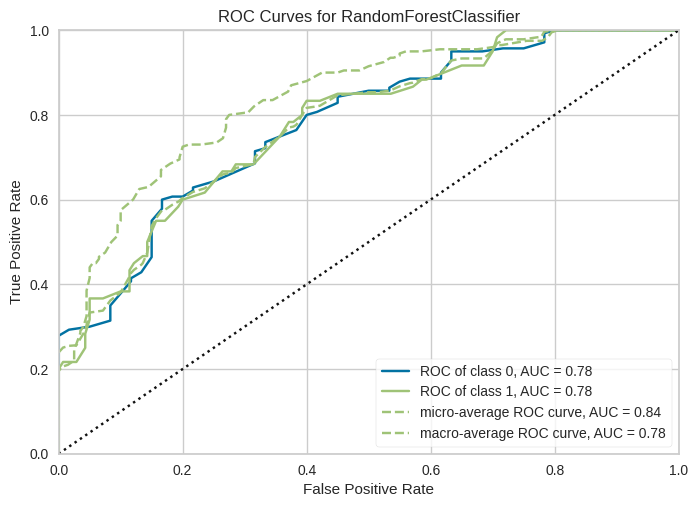

In [ ]:
from pycaret.classification import plot_model

exp.plot_model(best_model, plot = 'auc')
# 0: 1 and 1: 2

In [ ]:
type(best_model).__name__

'RandomForestClassifier'

# TSTR

In [ ]:
# SYNTHETIC DATASETS
synthetic_datasets = {
    'config default': pd.read_csv('/content/drive/MyDrive/Thesis/Datasets/synthetic_data_default.csv'),
    'config 1': pd.read_csv('/content/drive/MyDrive/Thesis/Datasets/synthetic_data_config#1.csv'),
    'config 2': pd.read_csv('/content/drive/MyDrive/Thesis/Datasets/synthetic_data_config#2.csv'),
    'config 3': pd.read_csv('/content/drive/MyDrive/Thesis/Datasets/synthetic_data_config#3.csv'),
    'config 4': pd.read_csv('/content/drive/MyDrive/Thesis/Datasets/synthetic_data_config#4.csv'),
    'config 5': pd.read_csv('/content/drive/MyDrive/Thesis/Datasets/synthetic_data_config#5.csv'),
    'config 6': pd.read_csv('/content/drive/MyDrive/Thesis/Datasets/synthetic_data_config#6.csv'),
    'config 7': pd.read_csv('/content/drive/MyDrive/Thesis/Datasets/synthetic_data_config#7.csv'),
    'config 8': pd.read_csv('/content/drive/MyDrive/Thesis/Datasets/synthetic_data_config#8.csv'),
    'config 9': pd.read_csv('/content/drive/MyDrive/Thesis/Datasets/synthetic_data_config#9.csv'),
    # 'config 10': pd.read_csv('/content/drive/MyDrive/Thesis/Datasets/synthetic_data_config#10.csv'),
    # 'config 11': pd.read_csv('/content/drive/MyDrive/Thesis/Datasets/synthetic_data_config#11.csv'),
    'config 12': pd.read_csv('/content/drive/MyDrive/Thesis/Datasets/synthetic_data_config#12.csv'),
    'config 13': pd.read_csv('/content/drive/MyDrive/Thesis/Datasets/synthetic_data_config#13.csv'),
    'config 14': pd.read_csv('/content/drive/MyDrive/Thesis/Datasets/synthetic_data_config#14.csv'),
    'config 15': pd.read_csv('/content/drive/MyDrive/Thesis/Datasets/synthetic_data_config#15.csv'),
    'config 16': pd.read_csv('/content/drive/MyDrive/Thesis/Datasets/synthetic_data_config#16.csv'),
    'config 17': pd.read_csv('/content/drive/MyDrive/Thesis/Datasets/synthetic_data_config#17.csv'),

}


In [ ]:
for config_name, synth_df in synthetic_datasets.items():
    print(f"\n=== TSTR: {config_name} ===")
    exp = ClassificationExperiment()
    exp.setup(
        data=synth_df,
        test_data=real_test,  # same real data used in TRTR
        target="target",
        session_id=42,
        index=False
    )

    exp.add_metric(
    id="f1_macro",
    name="F1(macro)",
    score_func=f1_macro,
    greater_is_better=True
    )

    exp.add_metric(
    id="g_mean",
    name="G-Mean(Multiclass)",
    score_func=g_score,
    greater_is_better=True
    )

    exp.create_model("rf", cross_validation=False)
    results = exp.pull()



=== TSTR: config default ===


,Description,Value
0,Session id,42
1,Target,target
2,Target type,Binary
3,Target mapping,"1: 0, 2: 1"
4,Original data shape,"(1200, 22)"
5,Transformed data shape,"(1200, 60)"
6,Transformed train set shape,"(1000, 60)"
7,Transformed test set shape,"(200, 60)"
8,Numeric features,7
9,Categorical features,14


,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,F1(macro),G-Mean(Multiclass)
Test,0.6950,0.6053,0.6950,0.4889,0.5740,-0.0099,-0.0464,0.4100,0.0000


Processing:   0%|          | 0/4 [00:00<?, ?it/s]


=== TSTR: config 1 ===


...

Processing:   0%|          | 0/4 [00:00<?, ?it/s]


=== TSTR: config 17 ===


,Description,Value
0,Session id,42
1,Target,target
2,Target type,Binary
3,Target mapping,"1: 0, 2: 1"
4,Original data shape,"(1200, 22)"
5,Transformed data shape,"(1200, 60)"
6,Transformed train set shape,"(1000, 60)"
7,Transformed test set shape,"(200, 60)"
8,Numeric features,7
9,Categorical features,14


,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,F1(macro),G-Mean(Multiclass)
Test,0.7150,0.7369,0.7150,0.6889,0.6892,0.2297,0.2441,0.6066,0.5296


Processing:   0%|          | 0/4 [00:00<?, ?it/s]

ROC config 16

In [ ]:
exp = ClassificationExperiment()
exp.setup(
    data=pd.read_csv('/content/drive/MyDrive/Thesis/Datasets/synthetic_data_config#16.csv'),
    test_data=real_test,
    target="target",
    session_id=42,
    index=False
)
exp.add_metric(
id="f1_macro",
name="F1(macro)",
score_func=f1_macro,
greater_is_better=True
)

exp.add_metric(
id="g_mean",
name="G-Mean(Multiclass)",
score_func=g_score,
greater_is_better=True
)
exp.create_model("rf", cross_validation=False)
results = exp.pull()

,Description,Value
0,Session id,42
1,Target,target
2,Target type,Binary
3,Target mapping,"1: 0, 2: 1"
4,Original data shape,"(1200, 22)"
5,Transformed data shape,"(1200, 60)"
6,Transformed train set shape,"(1000, 60)"
7,Transformed test set shape,"(200, 60)"
8,Numeric features,7
9,Categorical features,14


,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,F1(macro),G-Mean(Multiclass)
Test,0.7500,0.7365,0.7500,0.7337,0.7286,0.3280,0.3465,0.6573,0.5897


Processing:   0%|          | 0/4 [00:00<?, ?it/s]

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,F1(macro),G-Mean(Multiclass)
Test,0.7500,0.7365,0.7500,0.7337,0.7286,0.3280,0.3465,0.6573,0.5897


Processing:   0%|          | 0/4 [00:00<?, ?it/s]

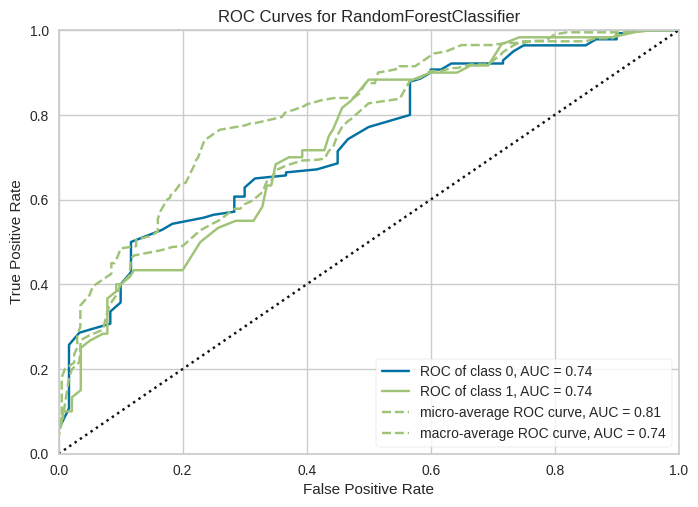

In [ ]:
model_config_16 = exp.create_model("rf", cross_validation=False)
exp.plot_model(model_config_16, plot = 'auc')

ROC config 17

In [ ]:
exp = ClassificationExperiment()
exp.setup(
    data=pd.read_csv('/content/drive/MyDrive/Thesis/Datasets/synthetic_data_config#17.csv'),
    test_data=real_test,
    target="target",
    session_id=42,
    index=False
)
exp.add_metric(
id="f1_macro",
name="F1(macro)",
score_func=f1_macro,
greater_is_better=True
)

exp.add_metric(
id="g_mean",
name="G-Mean(Multiclass)",
score_func=g_score,
greater_is_better=True
)

,Description,Value
0,Session id,42
1,Target,target
2,Target type,Binary
3,Target mapping,"1: 0, 2: 1"
4,Original data shape,"(1200, 22)"
5,Transformed data shape,"(1200, 60)"
6,Transformed train set shape,"(1000, 60)"
7,Transformed test set shape,"(200, 60)"
8,Numeric features,7
9,Categorical features,14


,g_mean
Name,G-Mean(Multiclass)
Display Name,G-Mean(Multiclass)
Score Function,<pycaret.internal.metrics.EncodedDecodedLabels...
Scorer,"make_scorer(g_score, response_method='predict')"
Target,pred
Args,{}
Greater is Better,True
Multiclass,True
Custom,True


,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,F1(macro),G-Mean(Multiclass)
Test,0.7150,0.7369,0.7150,0.6889,0.6892,0.2297,0.2441,0.6066,0.5296


Processing:   0%|          | 0/4 [00:00<?, ?it/s]

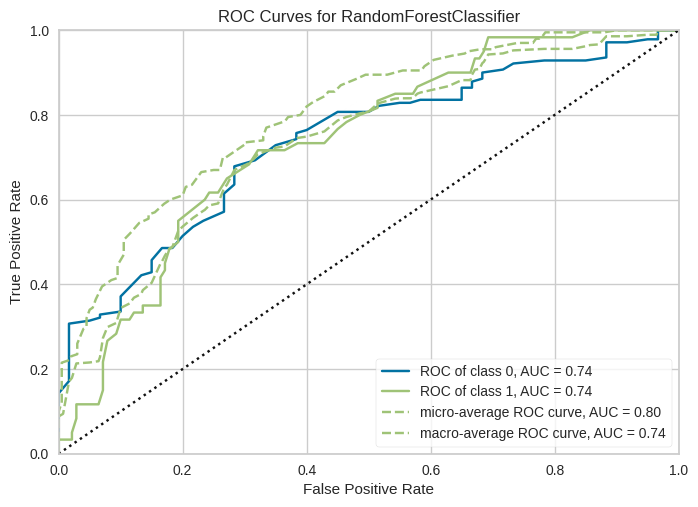

In [ ]:
model_config_17 = exp.create_model("rf", cross_validation=False)
exp.plot_model(model_config_17, plot = 'auc')